# EuroSAT: MLP, CNN and transfer learning

An original PyTorch implementation extending an image-classification exercise from my deep learning teaching.
Six configurations compare the learning rate, CNN width and transfer learning on the same split.

**Completed on a Colab Tesla T4.** The model selected on validation, partially fine-tuned MobileNetV2,
reaches **95.22% test accuracy and 0.9502 macro-F1** on 5,400 images. The outputs below are from this run;
the comparison chart and interpretation were added afterwards using its saved results.

To rerun: select **T4 GPU**, keep Colab's installed packages and run the cells in order.
Drive backup is enabled; choose a new `RUN_NAME` for a fresh experiment. No repository clone is needed.


## 1. Environment and settings

Use Colab's installed PyTorch and Torchvision together. Do not replace them with a CPU build.
The first cell prints the actual versions and device; there is no silent setup check.


In [1]:
import hashlib
from importlib.metadata import version
import json
import platform
import random
import sys
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.datasets.utils import download_and_extract_archive
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

SEED = 42
BATCH_SIZE = 128
NUM_WORKERS = 2
SAVE_TO_DRIVE = True
RUN_NAME = "run-01"  # Use a new name if you change the experiment or training code.
IMPLEMENTATION_VERSION = "110f2c396a1f3998"  # Manual label: update after code changes.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"  # FP16 autocast + gradient scaling on T4.

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)
ENVIRONMENT = {
    "python": platform.python_version(), "torch": torch.__version__,
    "torchvision": torchvision.__version__, "cuda": torch.version.cuda,
    "device": torch.cuda.get_device_name(0) if USE_AMP else "CPU", "amp": USE_AMP,
    "packages": {name: version(name) for name in (
        "torch", "torchvision", "numpy", "pandas", "scikit-learn", "matplotlib", "Pillow")},
}
print(json.dumps(ENVIRONMENT, indent=2))
if not USE_AMP:
    print("CPU detected. In Colab, select Runtime > Change runtime type > T4 GPU before continuing.")


{
  "python": "3.13.15",
  "torch": "2.11.0+cu128",
  "torchvision": "0.26.0+cu128",
  "cuda": "12.8",
  "device": "Tesla T4",
  "amp": true,
  "packages": {
    "torch": "2.11.0+cu128",
    "torchvision": "0.26.0+cu128",
    "numpy": "2.1.3",
    "pandas": "2.2.3",
    "scikit-learn": "1.6.1",
    "matplotlib": "3.10.0",
    "Pillow": "11.3.0"
  }
}


In [2]:
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK_ROOT = Path("/content/drive/MyDrive/eurosat-pytorch")
else:
    WORK_ROOT = Path.cwd() / "eurosat-work"

RUN_DIR = WORK_ROOT / RUN_NAME
RESULTS = RUN_DIR / "results"
WEIGHTS = RUN_DIR / "weights"
DATA_DIR = Path("/content/eurosat-data") if Path("/content").exists() else Path("data/eurosat")
for folder in (RESULTS, WEIGHTS, DATA_DIR):
    folder.mkdir(parents=True, exist_ok=True)

def write_json(path, value):
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
    temporary.replace(path)

print("Results and checkpoints:", RUN_DIR)
print("Completed experiments are reused. An interrupted experiment restarts from epoch 1.")


Mounted at /content/drive
Results and checkpoints: /content/drive/MyDrive/eurosat-pytorch/run-01
Completed experiments are reused. An interrupted experiment restarts from epoch 1.


## 2. Data and a fixed split

EuroSAT RGB contains 27,000 labelled Sentinel-2 image patches, 64 × 64 pixels, in ten land-cover
classes. The download below uses the archive URL and checksum published in Torchvision.
No account is required. The data stays outside the repository.

We hash **decoded RGB pixels**, remove exact duplicate images, and make our own stratified
**60% train / 20% validation / 20% test** split. Filenames, hashes and assignments are exported.
This is an image-level split: it does **not** establish generalization to new regions or seasons,
and exact deduplication does not remove near-duplicates or spatial correlations.

This run found **no exact duplicates**. The split contains **16,200 training, 5,400 validation and
5,400 test images**, with all ten classes represented in each part.


In [3]:
DATA_URL = (
    "https://huggingface.co/datasets/torchgeo/eurosat/resolve/"
    "c877bcd43f099cd0196738f714544e355477f3fd/EuroSAT.zip"
)
DATA_MD5 = "c8fa014336c82ac7804f0398fcb19387"
if not (DATA_DIR / "2750").exists():
    download_and_extract_archive(DATA_URL, str(DATA_DIR), md5=DATA_MD5)

catalog = ImageFolder(DATA_DIR / "2750")
CLASS_NAMES = catalog.classes
N_CLASSES = len(CLASS_NAMES)
assert len(catalog) == 27000 and N_CLASSES == 10, "Unexpected EuroSAT archive contents."

records = []
for path, label in catalog.samples:
    with Image.open(path) as image:
        pixels = np.asarray(image.convert("RGB"))
        assert pixels.shape == (64, 64, 3)
        digest = hashlib.sha256(pixels.tobytes()).hexdigest()
    records.append({"image_id": str(Path(path).relative_to(DATA_DIR / "2750")),
                    "label": label, "pixel_sha256": digest})
manifest = pd.DataFrame(records)
assert manifest.groupby("pixel_sha256").label.nunique().max() == 1, "Duplicate with conflicting labels."
duplicates = manifest[manifest.duplicated("pixel_sha256", keep="first")]
manifest = manifest.drop_duplicates("pixel_sha256").reset_index(drop=True)

train_idx, held_idx = train_test_split(
    manifest.index, test_size=0.4, stratify=manifest.label, random_state=SEED
)
val_idx, test_idx = train_test_split(
    held_idx, test_size=0.5, stratify=manifest.loc[held_idx, "label"], random_state=SEED
)
manifest["split"] = "train"
manifest.loc[val_idx, "split"] = "validation"
manifest.loc[test_idx, "split"] = "test"
manifest_text = manifest.to_csv(index=False)
if (RESULTS / "splits.csv").exists():
    assert (RESULTS / "splits.csv").read_text() == manifest_text, "Split changed: choose a new RUN_NAME."
(RESULTS / "splits.csv").write_text(manifest_text)
duplicates.to_csv(RESULTS / "removed_duplicates.csv", index=False)
print(f"Loaded {len(catalog):,} images; removed {len(duplicates)} exact duplicates.")
display(pd.crosstab(manifest.label.map(dict(enumerate(CLASS_NAMES))), manifest.split))


100%|██████████| 94.3M/94.3M [00:00<00:00, 95.2MB/s]


Loaded 27,000 images; removed 0 exact duplicates.


split,test,train,validation
label,,,
AnnualCrop,600,1800,600
Forest,600,1800,600
HerbaceousVegetation,600,1800,600
Highway,500,1500,500
Industrial,500,1500,500
Pasture,400,1200,400
PermanentCrop,500,1500,500
Residential,600,1800,600
River,500,1500,500


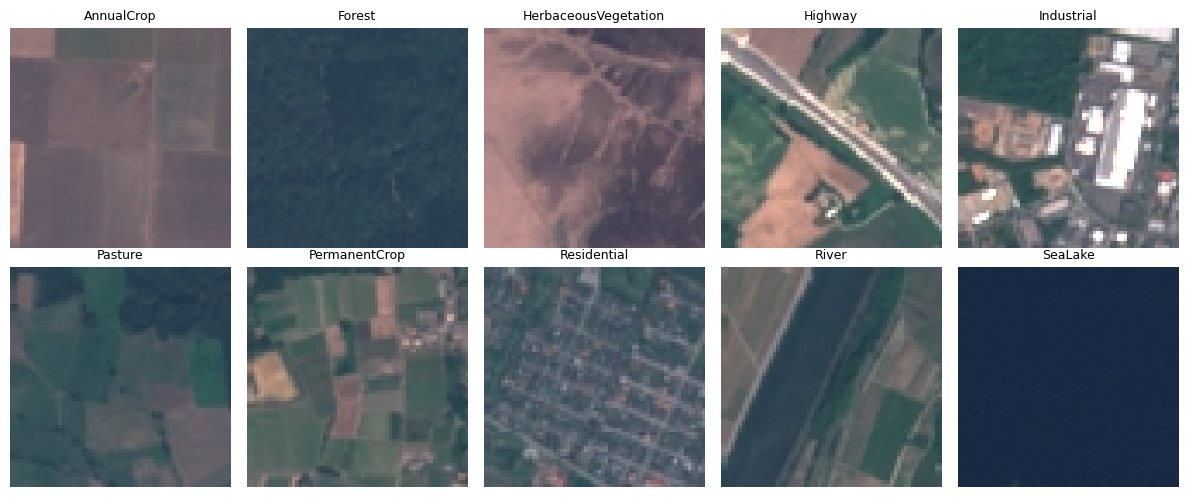

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for label, ax in enumerate(axes.flat):
    row = manifest[(manifest.label == label) & (manifest.split == "train")].iloc[0]
    with Image.open(DATA_DIR / "2750" / row.image_id) as image:
        ax.imshow(image)
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis("off")
fig.tight_layout()
fig.savefig(RESULTS / "sample_images.png", dpi=140, bbox_inches="tight")
plt.show()


## 3. Six experiments

The first two runs change only the MLP learning rate; the next two change only CNN width.
Both comparisons use the same seed, split, batch size, optimizer and epoch budget within each pair.
The final pair compares a frozen pretrained backbone with partial fine-tuning from its best checkpoint.

All models use ImageNet normalization. MLP/CNN use native 64 × 64 images; MobileNet uses the full
patch resized to 128 × 128 to keep T4 cost moderate. This differs from its standard ImageNet
evaluation transform. Thus the transfer comparison includes **pretraining and input resolution**;
it is not a pure architecture ablation. No data augmentation in this initial experiment.


In [5]:
EXPERIMENTS = [
    {"name": "mlp_lr_1e3", "kind": "mlp", "lr": 1e-3, "epochs": 12, "size": 64},
    {"name": "mlp_lr_3e4", "kind": "mlp", "lr": 3e-4, "epochs": 12, "size": 64},
    {"name": "cnn_small", "kind": "cnn", "width": 16, "lr": 1e-3, "epochs": 12, "size": 64},
    {"name": "cnn_wide", "kind": "cnn", "width": 32, "lr": 1e-3, "epochs": 12, "size": 64},
    {"name": "mobilenet_frozen", "kind": "frozen", "lr": 1e-3, "epochs": 8, "size": 128},
    {"name": "mobilenet_finetuned", "kind": "finetune", "lr": 1e-5, "epochs": 5, "size": 128},
]
WEIGHT_DECAY = 1e-4
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)
display(pd.DataFrame(EXPERIMENTS).fillna("—"))


,name,kind,lr,epochs,size,width
0,mlp_lr_1e3,mlp,0.00100,12,64,—
1,mlp_lr_3e4,mlp,0.00030,12,64,—
2,cnn_small,cnn,0.00100,12,64,16.0
3,cnn_wide,cnn,0.00100,12,64,32.0
4,mobilenet_frozen,frozen,0.00100,8,128,—
5,mobilenet_finetuned,finetune,0.00001,5,128,—


In [6]:
class PatchDataset(Dataset):
    def __init__(self, split, size):
        self.rows = manifest[manifest.split == split].reset_index(drop=True)
        self.transform = transforms.Compose([
            transforms.Resize((size, size), antialias=True),
            transforms.ToTensor(), transforms.Normalize(MEAN, STD),
        ])

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows.iloc[index]
        with Image.open(DATA_DIR / "2750" / row.image_id) as image:
            x = self.transform(image.convert("RGB"))
        return x, int(row.label), row.image_id

def make_loader(split, size):
    return DataLoader(
        PatchDataset(split, size), batch_size=BATCH_SIZE, shuffle=split == "train",
        generator=torch.Generator().manual_seed(SEED), num_workers=NUM_WORKERS,
        pin_memory=USE_AMP, persistent_workers=NUM_WORKERS > 0,
    )


### Models

The MLP uses one hidden layer of 256 units. The CNN has three Conv–BatchNorm–ReLU–Pool blocks,
global average pooling and a linear classifier. Doubling its width changes capacity while
preserving depth. Both use dropout 0.2.

MobileNetV2 starts from `IMAGENET1K_V2`. First, only its new classifier learns. Fine-tuning then
unfreezes its last three feature blocks (two inverted residual blocks and the final convolution),
with a smaller learning rate. BatchNorm affine parameters **and running statistics stay frozen**.


In [7]:
class SmallCNN(nn.Module):
    def __init__(self, width):
        super().__init__()
        layers, channels = [], 3
        for out_channels in (width, width * 2, width * 4):
            layers += [nn.Conv2d(channels, out_channels, 3, padding=1, bias=False),
                       nn.BatchNorm2d(out_channels), nn.ReLU(), nn.MaxPool2d(2)]
            channels = out_channels
        self.net = nn.Sequential(*layers, nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                 nn.Dropout(0.2), nn.Linear(channels, N_CLASSES))

    def forward(self, x):
        return self.net(x)

def build_model(spec, pretrained=True):
    if spec["kind"] == "mlp":
        return nn.Sequential(nn.Flatten(), nn.Linear(3 * 64 * 64, 256), nn.ReLU(),
                             nn.Dropout(0.2), nn.Linear(256, N_CLASSES))
    if spec["kind"] == "cnn":
        return SmallCNN(spec["width"])
    weights = MobileNet_V2_Weights.IMAGENET1K_V2 if pretrained else None
    model = mobilenet_v2(weights=weights)
    model.classifier[1] = nn.Linear(model.last_channel, N_CLASSES)
    for parameter in model.features.parameters():
        parameter.requires_grad = False
    if spec["kind"] == "finetune":
        for parameter in model.features[-3:].parameters():
            parameter.requires_grad = True
        for module in model.features.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.requires_grad_(False)
    return model

def train_mode(model, spec):
    model.train()
    if spec["kind"] in ("frozen", "finetune"):
        model.features.eval()  # BN running statistics must not update after model.train().


## 4. Training loop

AdamW, cross-entropy and a fixed epoch budget. Each run saves the checkpoint with the best
**validation macro-F1**, breaking ties by validation loss. No scheduler or early stopping: the
learning-rate comparison remains easy to interpret. Gradient scaling supports FP16 training on T4.

The training loss is measured during updates (dropout active); validation metrics use evaluation
mode. Time includes training, validation and checkpoint writes, but excludes data download and
external ImageNet pretraining.


In [8]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    targets, probabilities, image_ids = [], [], []
    loss_sum = 0.0
    for images, labels, ids in loader:
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(images)
            loss = nn.functional.cross_entropy(logits, labels)
        loss_sum += loss.item() * len(labels)
        targets.extend(labels.cpu().tolist())
        probabilities.append(logits.float().softmax(1).cpu().numpy())
        image_ids.extend(ids)
    probabilities = np.concatenate(probabilities)
    targets = np.asarray(targets)
    predictions = probabilities.argmax(1)
    metrics = {"loss": loss_sum / len(targets),
               "accuracy": accuracy_score(targets, predictions),
               "macro_f1": f1_score(targets, predictions, labels=range(N_CLASSES),
                                    average="macro", zero_division=0)}
    return metrics, targets, probabilities, image_ids

def fit(spec):
    name = spec["name"]
    summary_path = RESULTS / f"{name}.json"
    checkpoint = WEIGHTS / f"{name}.pt"
    if summary_path.exists() and checkpoint.exists():
        print(name, "— completed, reusing saved results")
        return json.loads(summary_path.read_text())
    seed_everything(SEED)
    model = build_model(spec)
    if spec["kind"] == "finetune":
        model.load_state_dict(torch.load(WEIGHTS / "mobilenet_frozen.pt", map_location="cpu", weights_only=True))
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=spec["lr"], weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    train_loader, val_loader = make_loader("train", spec["size"]), make_loader("validation", spec["size"])
    history, best_key, best_epoch = [], (-1.0, -float("inf")), 0
    if USE_AMP:
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    started = time.perf_counter()
    for epoch in range(1, spec["epochs"] + 1):
        train_mode(model, spec)
        train_loss, examples = 0.0, 0
        for images, labels, _ in train_loader:
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                loss = nn.functional.cross_entropy(model(images), labels)
            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite loss in {name}, epoch {epoch}.")
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * len(labels)
            examples += len(labels)
        val, _, _, _ = evaluate(model, val_loader)
        history.append({"epoch": epoch, "train_loss": train_loss / examples,
                        "val_loss": val["loss"], "val_accuracy": val["accuracy"], "val_macro_f1": val["macro_f1"]})
        key = (val["macro_f1"], -val["loss"])
        if key > best_key:
            best_key, best_epoch = key, epoch
            state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            temporary = checkpoint.with_suffix(".tmp")
            torch.save(state, temporary)
            temporary.replace(checkpoint)
        pd.DataFrame(history).to_csv(RESULTS / f"{name}_history.csv", index=False)
        print(f"{name:22s} {epoch:02d}/{spec['epochs']:02d} | loss {train_loss/examples:.3f} | val F1 {val['macro_f1']:.4f}", flush=True)
    if USE_AMP:
        torch.cuda.synchronize()
    seconds = time.perf_counter() - started
    best = history[best_epoch - 1]
    summary = {**spec, "best_epoch": best_epoch, "val_macro_f1": best["val_macro_f1"],
               "val_accuracy": best["val_accuracy"], "val_loss": best["val_loss"],
               "stage_seconds": seconds, "total_seconds": seconds,
               "parameters": sum(p.numel() for p in model.parameters()),
               "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
               "peak_gpu_mb": torch.cuda.max_memory_allocated() / 2**20 if USE_AMP else None}
    if spec["kind"] == "finetune":
        summary["total_seconds"] += json.loads((RESULTS / "mobilenet_frozen.json").read_text())["stage_seconds"]
    write_json(summary_path, summary)
    del model, optimizer, train_loader, val_loader
    if USE_AMP:
        torch.cuda.empty_cache()
    return summary


### Lock this run and check the pipeline

Settings, data split and implementation version are saved before training. Reusing this run name
with a different recorded plan stops rather than mixing experiments.
`IMPLEMENTATION_VERSION` is a manual label, not an automatic code fingerprint. After editing code,
use a new `RUN_NAME` and update that label to identify the revision.
Completed experiments survive a runtime reset when Drive backup is enabled. Only completed runs
are resumed; a partially trained run is restarted from its initial weights.


In [9]:
PLAN = {"implementation": IMPLEMENTATION_VERSION, "seed": SEED, "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS, "weight_decay": WEIGHT_DECAY, "experiments": EXPERIMENTS,
        "data_url": DATA_URL, "archive_md5": DATA_MD5,
        "split_sha256": hashlib.sha256(manifest_text.encode()).hexdigest(),
        "classes": CLASS_NAMES, "normalization": {"mean": MEAN, "std": STD},
        "weights": "MobileNet_V2_Weights.IMAGENET1K_V2", "environment": ENVIRONMENT}
PLAN = json.loads(json.dumps(PLAN))
if (RESULTS / "plan.json").exists():
    assert json.loads((RESULTS / "plan.json").read_text()) == PLAN, "Plan or environment changed: use a new RUN_NAME."
else:
    write_json(RESULTS / "plan.json", PLAN)

check_loader = make_loader("train", 64)
images, labels, _ = next(iter(check_loader))
assert images.shape[1:] == (3, 64, 64) and labels.min() >= 0 and labels.max() < N_CLASSES
for spec in EXPERIMENTS:
    model = build_model(spec, pretrained=False).eval().to(DEVICE)
    with torch.inference_mode():
        output = model(torch.zeros(2, 3, spec["size"], spec["size"], device=DEVICE))
    assert output.shape == (2, N_CLASSES) and torch.isfinite(output).all()
del model, check_loader, images
if USE_AMP:
    torch.cuda.empty_cache()
print("Pipeline check passed: data, labels and all six model output shapes are correct.")


Pipeline check passed: data, labels and all six model output shapes are correct.


## 5. Run the experiment

This is the long cell. Progress is printed after **each epoch**. A first epoch may take longer
because of initialization. Keep the browser session connected. Dataset/model downloads happen once.
The next cell plots validation results; the test set is still unused.


In [10]:
summaries = [fit(spec) for spec in EXPERIMENTS]
validation = pd.DataFrame(summaries).sort_values(
    ["val_macro_f1", "val_loss"], ascending=[False, True], kind="stable"
)
WINNER = validation.iloc[0]["name"]
validation.to_csv(RESULTS / "validation_results.csv", index=False)
write_json(RESULTS / "selection.json", {
    "winner": WINNER, "criterion": "highest validation macro-F1; then lowest validation loss",
    "test_used_for_selection": False,
})
display(validation[["name", "val_macro_f1", "val_accuracy", "best_epoch", "trainable_parameters", "total_seconds"]].round(4))
print("Selected on validation:", WINNER)


mlp_lr_1e3             01/12 | loss 2.811 | val F1 0.4398
mlp_lr_1e3             02/12 | loss 1.585 | val F1 0.4556
mlp_lr_1e3             03/12 | loss 1.477 | val F1 0.4898
mlp_lr_1e3             04/12 | loss 1.358 | val F1 0.4617
mlp_lr_1e3             05/12 | loss 1.291 | val F1 0.4869
mlp_lr_1e3             06/12 | loss 1.241 | val F1 0.5272
mlp_lr_1e3             07/12 | loss 1.212 | val F1 0.5251
mlp_lr_1e3             08/12 | loss 1.160 | val F1 0.4386
mlp_lr_1e3             09/12 | loss 1.167 | val F1 0.5535
mlp_lr_1e3             10/12 | loss 1.102 | val F1 0.5153
mlp_lr_1e3             11/12 | loss 1.100 | val F1 0.5344
mlp_lr_1e3             12/12 | loss 1.089 | val F1 0.5548
mlp_lr_3e4             01/12 | loss 1.900 | val F1 0.4521
mlp_lr_3e4             02/12 | loss 1.485 | val F1 0.4509
mlp_lr_3e4             03/12 | loss 1.403 | val F1 0.4730
mlp_lr_3e4             04/12 | loss 1.308 | val F1 0.5156
mlp_lr_3e4             05/12 | loss 1.223 | val F1 0.5283
mlp_lr_3e4    

100%|██████████| 13.6M/13.6M [00:00<00:00, 195MB/s]


mobilenet_frozen       01/08 | loss 0.672 | val F1 0.9082
mobilenet_frozen       02/08 | loss 0.288 | val F1 0.9205
mobilenet_frozen       03/08 | loss 0.232 | val F1 0.9284
mobilenet_frozen       04/08 | loss 0.202 | val F1 0.9325
mobilenet_frozen       05/08 | loss 0.185 | val F1 0.9318
mobilenet_frozen       06/08 | loss 0.169 | val F1 0.9333
mobilenet_frozen       07/08 | loss 0.161 | val F1 0.9353
mobilenet_frozen       08/08 | loss 0.150 | val F1 0.9350
mobilenet_finetuned    01/05 | loss 0.127 | val F1 0.9415
mobilenet_finetuned    02/05 | loss 0.111 | val F1 0.9435
mobilenet_finetuned    03/05 | loss 0.101 | val F1 0.9448
mobilenet_finetuned    04/05 | loss 0.091 | val F1 0.9464
mobilenet_finetuned    05/05 | loss 0.085 | val F1 0.9445


,name,val_macro_f1,val_accuracy,best_epoch,trainable_parameters,total_seconds
5,mobilenet_finetuned,0.9464,0.9483,4,1207690,330.5583
4,mobilenet_frozen,0.9353,0.9374,7,12810,203.9811
3,cnn_wide,0.8688,0.8733,8,94762,168.7388
2,cnn_small,0.8339,0.8391,12,24346,167.7298
1,mlp_lr_3e4,0.5662,0.5759,12,3148554,164.0523
0,mlp_lr_1e3,0.5548,0.5630,12,3148554,167.9331


Selected on validation: mobilenet_finetuned


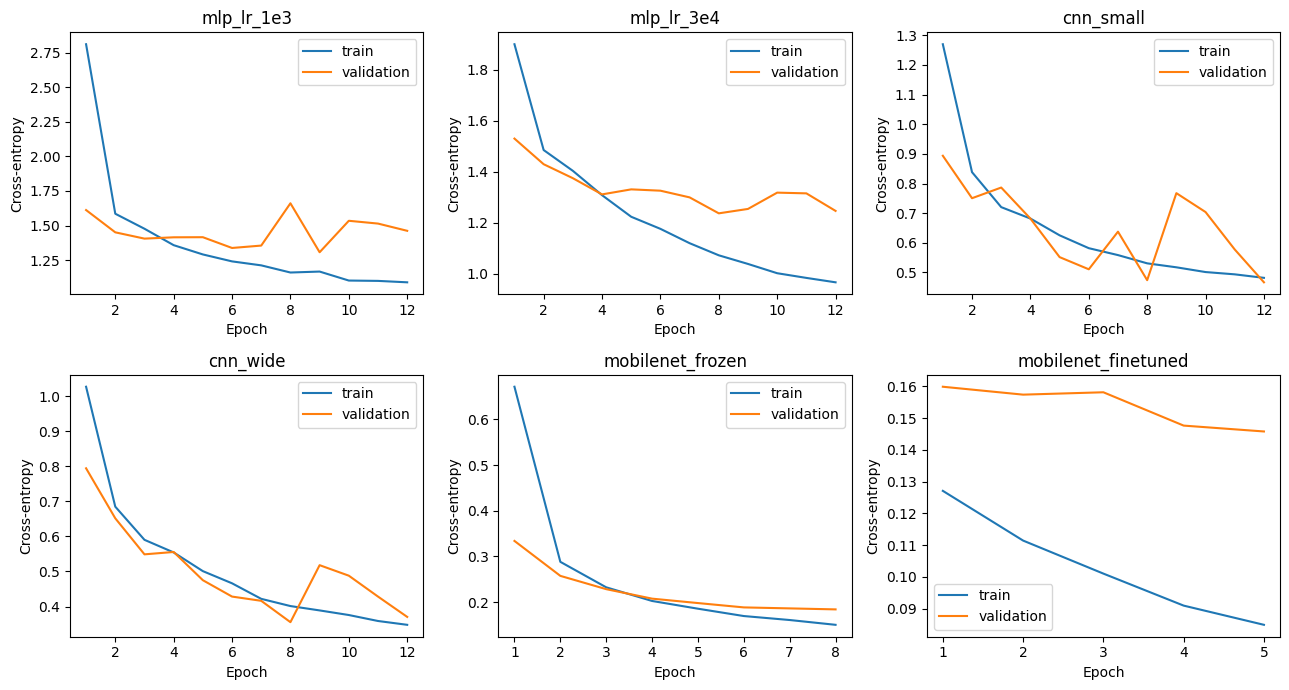

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for spec, ax in zip(EXPERIMENTS, axes.flat):
    history = pd.read_csv(RESULTS / f"{spec['name']}_history.csv")
    ax.plot(history.epoch, history.train_loss, label="train")
    ax.plot(history.epoch, history.val_loss, label="validation")
    ax.set(title=spec["name"], xlabel="Epoch", ylabel="Cross-entropy")
    ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "learning_curves.png", dpi=140, bbox_inches="tight")
plt.show()


### What the validation results show

- **Learning rate:** lowering the MLP rate from `1e-3` to `3e-4` raises its best macro-F1 from
  **0.5548 to 0.5662**. Both peak at epoch 12; this short run does not establish convergence.
  Flattening keeps the pixel values and their order, but the MLP has no convolutional weight sharing.
- **CNN width:** doubling the channels raises macro-F1 from **0.8339 to 0.8688**, with about
  **3.9×** as many parameters. The wide CNN peaks at epoch 8; its training loss continues falling
  afterwards without a better validation F1. This is why we reload the best checkpoint.
- **Transfer:** the frozen MobileNet already reaches **0.9353**, training only **12,810 parameters**.
  Partial fine-tuning raises this to **0.9464**, at epoch 4 of the extra five epochs.

**Selected on validation: `mobilenet_finetuned`.** Fine-tuning trains 1,207,690 parameters (54% of
the model), while BatchNorm stays frozen. Its stage takes 2 min 07 s; the complete frozen + fine-tuned
path takes **5 min 31 s**. All six training/validation stages total **16 min 39 s**, excluding downloads
and final test evaluation. These timings describe this Colab session.


## 6. Final test evaluation

The six configurations were defined in advance and the winner has already been selected on
validation. This cell evaluates their saved checkpoints on the same test images in one final
comparison. It also evaluates a majority-class baseline fitted only from training labels.

Do not tune configurations in response to these test scores. A later search would need a fresh
held-out evaluation. If this cell is rerun, it reuses its saved predictions.


In [12]:
test_rows = []
expected_test = manifest[manifest.split == "test"][["image_id", "label"]].rename(
    columns={"label": "true_label"}).reset_index(drop=True)
for spec in EXPERIMENTS:
    predictions_path = RESULTS / f"{spec['name']}_test_predictions.csv"
    if predictions_path.exists():
        predictions = pd.read_csv(predictions_path)
        assert predictions[["image_id", "true_label"]].equals(expected_test), (
            f"Incomplete or mismatched predictions: delete {predictions_path} and rerun this cell."
        )
    else:
        model = build_model(spec, pretrained=False)
        model.load_state_dict(torch.load(WEIGHTS / f"{spec['name']}.pt", map_location="cpu", weights_only=True))
        model.to(DEVICE)
        loader = make_loader("test", spec["size"])
        _, targets, probabilities, ids = evaluate(model, loader)
        predictions = pd.DataFrame({"image_id": ids, "true_label": targets,
                                    "predicted_label": probabilities.argmax(1), "confidence": probabilities.max(1)})
        for label in range(N_CLASSES):
            predictions[f"p_{label}"] = probabilities[:, label]
        temporary = predictions_path.with_suffix(".tmp")
        predictions.to_csv(temporary, index=False)
        temporary.replace(predictions_path)
        del model, loader
        if USE_AMP:
            torch.cuda.empty_cache()
    test_rows.append({"name": spec["name"],
                      "test_accuracy": accuracy_score(predictions.true_label, predictions.predicted_label),
                      "test_macro_f1": f1_score(predictions.true_label, predictions.predicted_label,
                                                labels=range(N_CLASSES), average="macro", zero_division=0)})

comparison = validation.merge(pd.DataFrame(test_rows), on="name")
comparison["selected_on_validation"] = comparison.name == WINNER
comparison.to_csv(RESULTS / "comparison.csv", index=False)
display(comparison[["name", "val_macro_f1", "test_macro_f1", "test_accuracy", "trainable_parameters", "total_seconds", "selected_on_validation"]].round(4))
majority = int(manifest[manifest.split == "train"].label.mode().iloc[0])
targets = manifest[manifest.split == "test"].label.to_numpy()
baseline = {"class": CLASS_NAMES[majority], "test_accuracy": float(np.mean(targets == majority)),
            "test_macro_f1": f1_score(targets, np.full_like(targets, majority),
                                      labels=range(N_CLASSES), average="macro", zero_division=0)}
write_json(RESULTS / "majority_baseline.json", baseline)
print("Majority-class baseline:", baseline)


,name,val_macro_f1,test_macro_f1,test_accuracy,trainable_parameters,total_seconds,selected_on_validation
0,mobilenet_finetuned,0.9464,0.9502,0.9522,1207690,330.5583,True
1,mobilenet_frozen,0.9353,0.9377,0.9400,12810,203.9811,False
2,cnn_wide,0.8688,0.8671,0.8722,94762,168.7388,False
3,cnn_small,0.8339,0.8330,0.8394,24346,167.7298,False
4,mlp_lr_3e4,0.5662,0.5607,0.5698,3148554,164.0523,False
5,mlp_lr_1e3,0.5548,0.5348,0.5433,3148554,167.9331,False


Majority-class baseline: {'class': 'AnnualCrop', 'test_accuracy': 0.1111111111111111, 'test_macro_f1': 0.02}


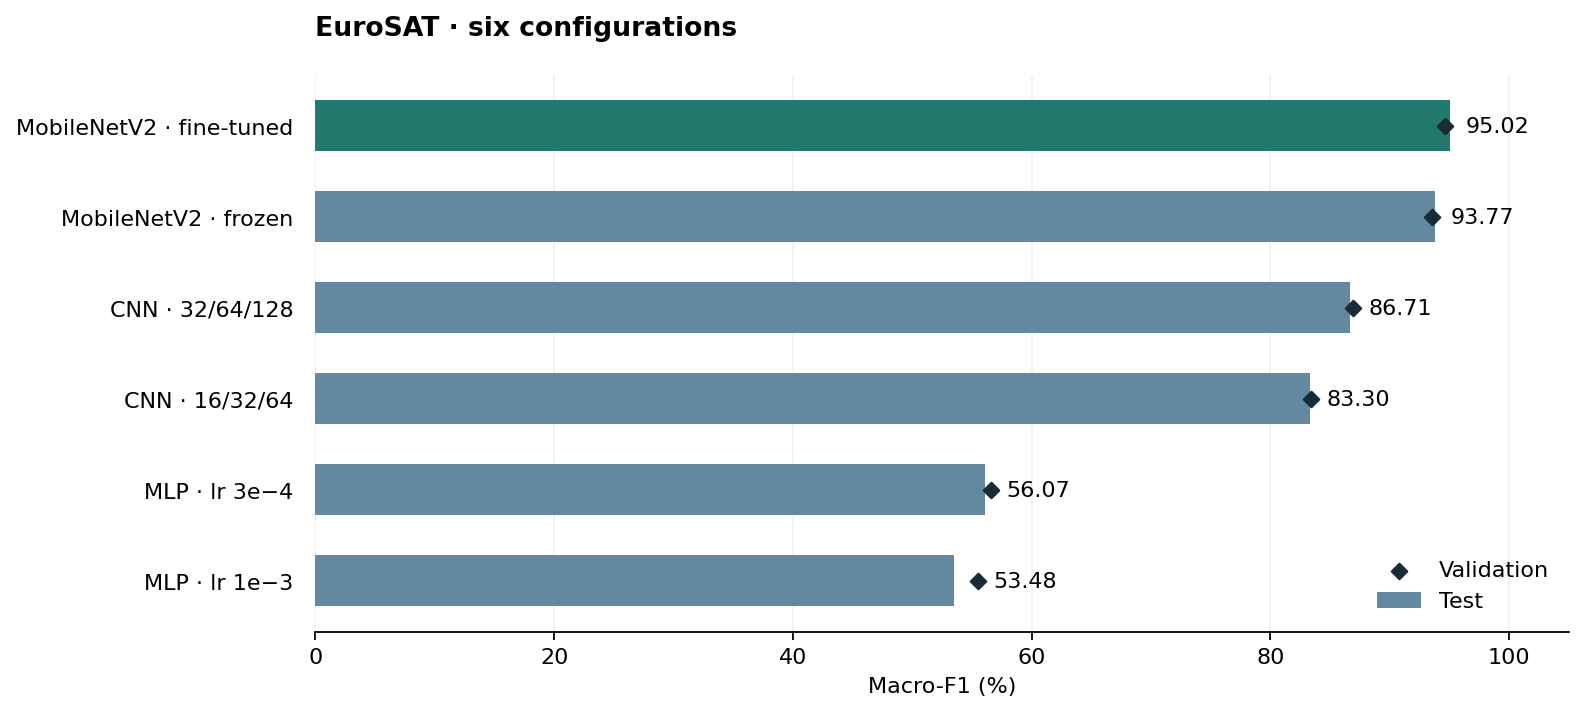

In [16]:
labels = {
    "mlp_lr_1e3": "MLP · lr 1e−3", "mlp_lr_3e4": "MLP · lr 3e−4",
    "cnn_small": "CNN · 16/32/64", "cnn_wide": "CNN · 32/64/128",
    "mobilenet_frozen": "MobileNetV2 · frozen", "mobilenet_finetuned": "MobileNetV2 · fine-tuned",
}
plot = comparison.iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 4.6))
colors = ["#24796f" if selected else "#63889f" for selected in plot.selected_on_validation]
ax.barh(plot.index, 100 * plot.test_macro_f1, height=0.56, color=colors, label="Test")
ax.scatter(100 * plot.val_macro_f1, plot.index, color="#182c38", marker="D", s=24,
           zorder=3, label="Validation")
for i, row in plot.iterrows():
    ax.text(100 * max(row.test_macro_f1, row.val_macro_f1) + 1.3, i,
            f"{100 * row.test_macro_f1:.2f}", va="center", fontsize=10)
ax.set_yticks(plot.index, [labels[name] for name in plot.name])
ax.set_xlim(0, 105)
ax.set_xticks(range(0, 101, 20))
ax.set_xlabel("Macro-F1 (%)")
ax.set_title("EuroSAT · six configurations", loc="left", pad=18, weight="bold")
ax.grid(axis="x", alpha=0.18)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(RESULTS / "comparison.png", dpi=160, bbox_inches="tight")
plt.show()


## 7. Inspect the selected model's errors

The selected checkpoint gets **5,142 / 5,400** test images right: **95.22% accuracy, 0.9502 macro-F1**.
The frozen model gets 5,076 right. Fine-tuning corrects 99 of its errors but introduces 33 new ones,
for a net gain of **66 images (+1.22 percentage points)**. This also uses five extra training epochs.

Among the 258 remaining errors, the main confusions are **River / Highway** (39 in both directions)
and **PermanentCrop / HerbaceousVegetation** (38). PermanentCrop has the lowest class F1 (**0.9144**);
SeaLake has the highest (**0.9892**).

The confusion matrix is normalized by true class. The images below are the most confident mistakes,
not a random sample. **68 errors have a softmax score of at least 0.90**: a high score does not guarantee
correctness. Displayed scores are rounded; `1.00` does not mean certainty.


,precision,recall,f1-score,support
AnnualCrop,0.958,0.958,0.958,600.000
Forest,0.976,0.962,0.969,600.000
HerbaceousVegetation,0.919,0.950,0.934,600.000
Highway,0.923,0.916,0.920,500.000
Industrial,0.961,0.988,0.974,500.000
Pasture,0.932,0.922,0.927,400.000
PermanentCrop,0.921,0.908,0.914,500.000
Residential,0.987,0.980,0.983,600.000
River,0.941,0.924,0.932,500.000
SeaLake,0.987,0.992,0.989,600.000


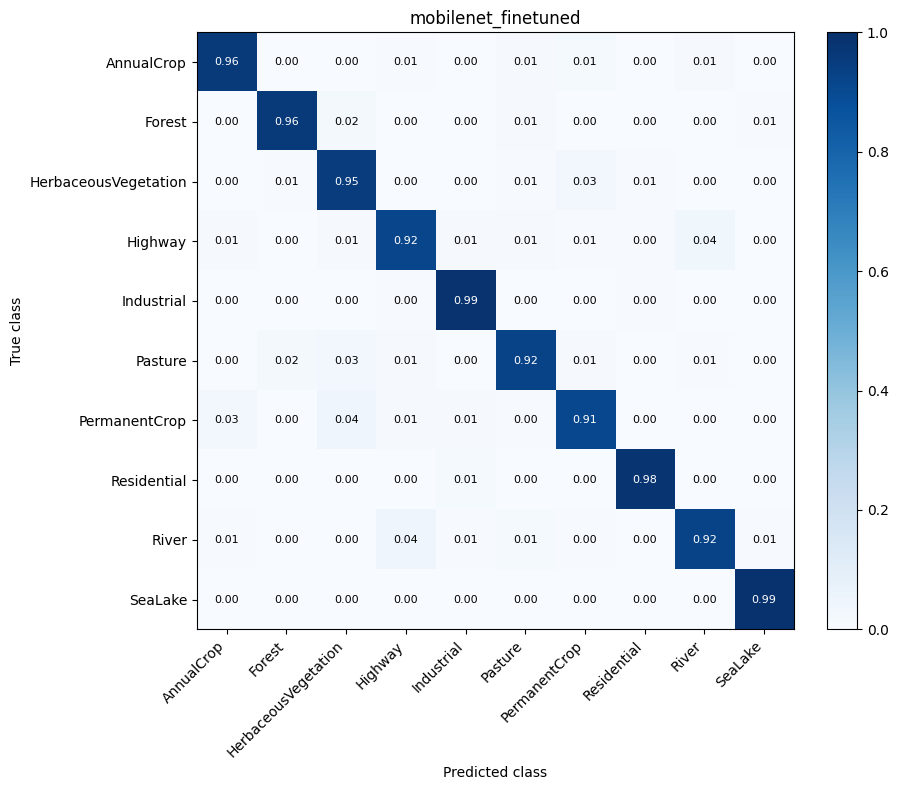

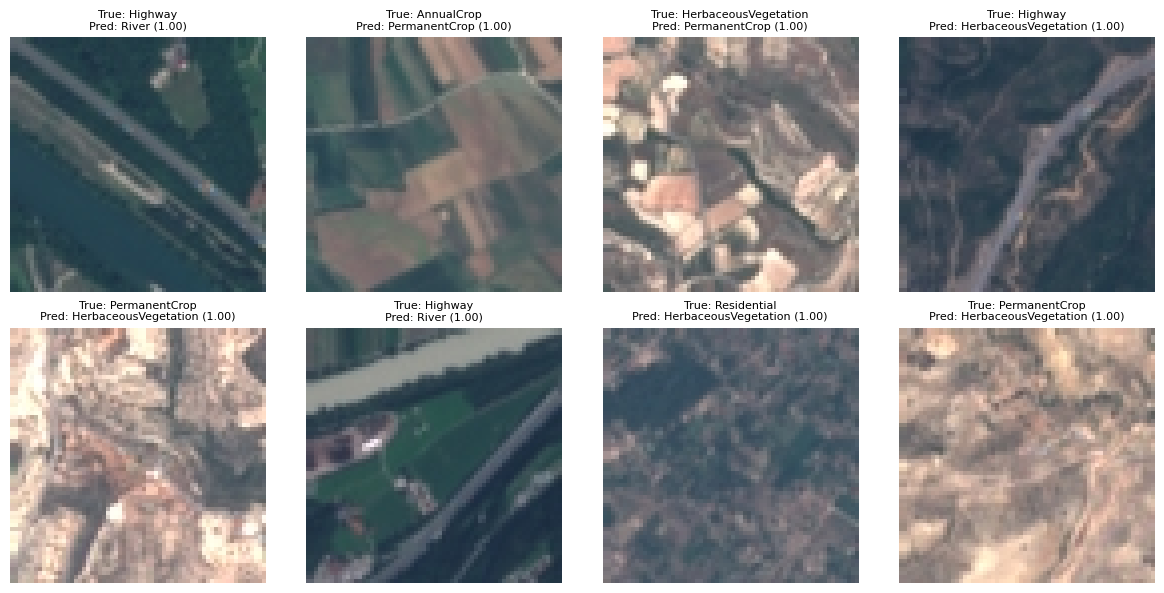

In [13]:
selected_predictions = pd.read_csv(RESULTS / f"{WINNER}_test_predictions.csv")
truth, predicted = selected_predictions.true_label, selected_predictions.predicted_label
report = classification_report(truth, predicted, labels=range(N_CLASSES), target_names=CLASS_NAMES,
                               output_dict=True, zero_division=0)
pd.DataFrame(report).T.to_csv(RESULTS / "per_class_metrics.csv")
display(pd.DataFrame(report).T.round(3))
cm = confusion_matrix(truth, predicted, labels=range(N_CLASSES))
pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(RESULTS / "confusion_counts.csv")
normalized = cm / np.maximum(cm.sum(1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
ax.set(xticks=range(N_CLASSES), yticks=range(N_CLASSES), xticklabels=CLASS_NAMES,
       yticklabels=CLASS_NAMES, xlabel="Predicted class", ylabel="True class", title=WINNER)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f"{normalized[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if normalized[i, j] > .5 else "black")
fig.colorbar(im, ax=ax, fraction=.046)
fig.tight_layout()
fig.savefig(RESULTS / "confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()

mistakes = selected_predictions[truth != predicted].sort_values("confidence", ascending=False).head(8)
if len(mistakes):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax in axes.flat:
        ax.axis("off")
    for (_, row), ax in zip(mistakes.iterrows(), axes.flat):
        with Image.open(DATA_DIR / "2750" / row.image_id) as image:
            ax.imshow(image)
        ax.set_title(f"True: {CLASS_NAMES[int(row.true_label)]}\nPred: {CLASS_NAMES[int(row.predicted_label)]} ({row.confidence:.2f})", fontsize=8)
    fig.tight_layout()
    fig.savefig(RESULTS / "confident_errors.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    print("No test errors to display. Verify this unexpected result before drawing conclusions.")


## 8. Reload, predict and export

The function below uses the same preprocessing as evaluation. The selected weights are saved
separately from the lightweight results ZIP. Drive holds every checkpoint when backup is enabled.
The archive contains the plan, environment, split, epoch histories, metrics, predictions and figures.


In [14]:
selected_spec = next(spec for spec in EXPERIMENTS if spec["name"] == WINNER)
selected_model = build_model(selected_spec, pretrained=False)
selected_model.load_state_dict(torch.load(WEIGHTS / f"{WINNER}.pt", map_location="cpu", weights_only=True))
selected_model.to(DEVICE).eval()
inference_transform = PatchDataset("test", selected_spec["size"]).transform

@torch.inference_mode()
def predict_image(path):
    with Image.open(path) as image:
        x = inference_transform(image.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
        probabilities = selected_model(x).float().softmax(1)[0]
    label = int(probabilities.argmax())
    return {"class": CLASS_NAMES[label], "confidence": float(probabilities[label]), "model": WINNER}

example_id = selected_predictions.iloc[0].image_id
print("Reloaded model:", predict_image(DATA_DIR / "2750" / example_id))
print("Known label:", CLASS_NAMES[int(selected_predictions.iloc[0].true_label)])

write_json(RESULTS / "environment.json", ENVIRONMENT)
(RESULTS / "requirements_run.txt").write_text("\n".join(
    f"{name}=={value}" for name, value in ENVIRONMENT["packages"].items()) + "\n")
archive = RUN_DIR / "eurosat-results.zip"
with zipfile.ZipFile(archive, "w", zipfile.ZIP_DEFLATED) as bundle:
    for path in sorted(RESULTS.iterdir()):
        if path.is_file():
            bundle.write(path, f"results/{path.name}")
print(f"Results ready: {archive} ({archive.stat().st_size / 2**20:.1f} MB)")
print("Best weights:", WEIGHTS / f"{WINNER}.pt")


Reloaded model: {'class': 'AnnualCrop', 'confidence': 0.9999960660934448, 'model': 'mobilenet_finetuned'}
Known label: AnnualCrop
Results ready: /content/drive/MyDrive/eurosat-pytorch/run-01/eurosat-results.zip (3.5 MB)
Best weights: /content/drive/MyDrive/eurosat-pytorch/run-01/weights/mobilenet_finetuned.pt


In [15]:
if "google.colab" in sys.modules:
    from google.colab import files
    files.download(str(archive))
else:
    print("Download the ZIP from:", archive)


### Scope and next steps

The saved predictions reproduce the six reported accuracy and macro-F1 scores. Histories, split IDs,
the validation selection and class-level counts are consistent. This checks the exported results;
it does not independently reproduce the GPU training.

This is one seed and a random image-level split, not a test on new geographic areas or seasons.
Exact deduplication does not remove spatial similarity. The CNN/transfer comparison changes
architecture, pretraining, input resolution and training budget together. Softmax is uncalibrated;
this is a small experiment, not production validation or a comparison at convergence.

A next experiment could repeat several seeds or use a geographic split where location metadata
is available. After inspecting these test results, further tuning needs a new untouched evaluation
set to support a fresh final claim.

**Saved evidence:** the repository combines the original histories and predictions into a few files
under `results/`; `run.json` records the plan, versions and selection. Weights remain in Drive.
To archive a new run, download its results ZIP and executed notebook from Colab.

**Sources:** [EuroSAT authors and data](https://github.com/phelber/EuroSAT) ·
[Torchvision dataset download](https://docs.pytorch.org/vision/stable/_modules/torchvision/datasets/eurosat.html) ·
[MobileNetV2 weights](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.mobilenet_v2.html) ·
[PyTorch mixed precision](https://docs.pytorch.org/tutorials/recipes/recipes/amp_recipe.html)
